# Two View Geometry

## Calibration

In [1]:
import glob, os
import cv2
import numpy as np

cv2.ocl.setUseOpenCL(False) 

pattern_size = (10, 7)      
square_size_mm = 24.0

img_paths = sorted(glob.glob("checkerboard/*.*"))
assert len(img_paths) > 0, "Nessuna immagine trovata in data/calib/"

cols, rows = pattern_size
objp = np.zeros((rows * cols, 3), np.float32)
objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)
objp *= square_size_mm

objpoints, imgpoints = [], []
img_size = None

os.makedirs("debug_corners", exist_ok=True)

ok = 0
for p in img_paths:
    img = cv2.imread(p)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_size = gray.shape[::-1]

    found, corners = cv2.findChessboardCornersSB(gray, pattern_size)

    if not found:
        print(f"[NO] {os.path.basename(p)}")
        continue

    objpoints.append(objp)
    imgpoints.append(corners)
    ok += 1
    print(f"[OK] {os.path.basename(p)}  corners={len(corners)}")

    vis = img.copy()
    cv2.drawChessboardCorners(vis, pattern_size, corners, found)
    cv2.imwrite(os.path.join("debug_corners", os.path.basename(p)), vis)

print(f"\nTrovate scacchiere in {ok}/{len(img_paths)} immagini")
assert ok >= 8, "Troppo poche immagini valide: punta a 10–20."

rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, img_size, None, None
)

mean_err = 0.0
for i in range(len(objpoints)):
    proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, dist)
    err = cv2.norm(imgpoints[i], proj, cv2.NORM_L2) / np.sqrt(len(proj))
    mean_err += err
mean_err /= len(objpoints)

print("\n=== RISULTATI ===")
print("RMS (calibrateCamera):", rms)
print("Mean reprojection error (px):", mean_err)
print("\nK =\n", K)
print("\ndist =\n", dist.ravel())

np.savez("camera_calib.npz",
         K=K, dist=dist, rms=rms, mean_reproj_error=mean_err,
         img_size=np.array(img_size), pattern_size=np.array(pattern_size),
         square_size_mm=square_size_mm)
print("\nSalvato: camera_calib.npz")
print("Debug corners salvati in: debug_corners/")

[OK] DSCF6339.JPG  corners=70
[OK] DSCF6340.JPG  corners=70
[NO] DSCF6341.JPG
[OK] DSCF6342.JPG  corners=70
[OK] DSCF6343.JPG  corners=70
[NO] DSCF6344.JPG
[NO] DSCF6345.JPG
[OK] DSCF6346.JPG  corners=70
[OK] DSCF6347.JPG  corners=70
[OK] DSCF6348.JPG  corners=70
[NO] DSCF6349.JPG
[NO] DSCF6350.JPG
[NO] DSCF6351.JPG
[OK] DSCF6352.JPG  corners=70
[OK] DSCF6353.JPG  corners=70
[NO] DSCF6354.JPG
[OK] DSCF6355.JPG  corners=70
[NO] DSCF6356.JPG
[NO] DSCF6357.JPG
[OK] DSCF6358.JPG  corners=70
[OK] DSCF6359.JPG  corners=70
[OK] DSCF6360.JPG  corners=70
[OK] DSCF6361.JPG  corners=70

Trovate scacchiere in 14/23 immagini

=== RISULTATI ===
RMS (calibrateCamera): 0.36689716564408814
Mean reprojection error (px): 0.3627500820747361

K =
 [[6.45164764e+03 0.00000000e+00 3.12323425e+03]
 [0.00000000e+00 6.45010489e+03 2.06515380e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

dist =
 [-0.05021708  0.07611484 -0.00029132  0.00095053  0.24201175]

Salvato: camera_calib.npz
Debug corners salvat

## Matches via SIFT

In [11]:
import os
import cv2
import numpy as np

img1_path = "object/img1.JPG"
img2_path = "object/img2.JPG"

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)
assert img1 is not None and img2 is not None, "Errore: immagini non lette. Controlla i path."

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

use_sift = hasattr(cv2, "SIFT_create")
if use_sift:
    feat = cv2.SIFT_create(nfeatures=10000)
    norm = cv2.NORM_L2
else:
    print("SIFT non disponibile: uso ORB (meno robusto).")
    feat = cv2.ORB_create(nfeatures=4000)
    norm = cv2.NORM_HAMMING

kp1, des1 = feat.detectAndCompute(gray1, None)
kp2, des2 = feat.detectAndCompute(gray2, None)
assert des1 is not None and des2 is not None, "Nessun descrittore trovato."

bf = cv2.BFMatcher(norm, crossCheck=False)
matches_knn = bf.knnMatch(des1, des2, k=2)

ratio = 0.75 if use_sift else 0.80
good = []
for m, n in matches_knn:
    if m.distance < ratio * n.distance:
        good.append(m)

print(f"Keypoints: img1={len(kp1)} img2={len(kp2)}")
print(f"Matches dopo ratio test: {len(good)}")
assert len(good) >= 12, "Troppi pochi match: prova a cambiare ratio o usa immagini con più texture."

# Punti corrispondenti in pixel (DISTORTI, dalle immagini originali)
pts1 = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 2)

# Visualizzazione di tutti i match post-ratio-test (senza RANSAC)
vis = cv2.drawMatches(
    img1, kp1, img2, kp2,
    good, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
cv2.imwrite(os.path.join(out_dir, "good_matches.png"), vis)

# Salva tutti i match post-ratio-test (senza filtraggio RANSAC)
np.savez(
    os.path.join(out_dir, "matches_px.npz"),
    pts1=pts1,
    pts2=pts2,
    undistorted=np.array([0], dtype=np.int32),   # esplicito: pixel distorti
    use_sift=np.array([1 if use_sift else 0], dtype=np.int32),
    ratio=np.array([ratio], dtype=np.float64),
)

print("Salvati:")
print(" - outputs/good_matches.png")
print(" - outputs/matches_px.npz")

Keypoints: img1=10001 img2=10000
Matches dopo ratio test: 1059
Salvati:
 - outputs/good_matches.png
 - outputs/matches_px.npz


## 8 points

In [25]:
import os
import glob
import numpy as np
import cv2

CALIB_PATH   = "camera_calib.npz"
MATCHES_PATH = "outputs/matches_px.npz"
IMG1_PATH    = "object/img1.JPG"
IMG2_PATH    = "object/img2.JPG"

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

RANSAC_ITERS = 5000
RANSAC_THRESH = 1e-6
RANSAC_SEED = 0

cal = np.load(CALIB_PATH)
K = cal["K"].astype(np.float64)
dist = cal["dist"].astype(np.float64)

m = np.load(MATCHES_PATH, allow_pickle=True)

pts1_in = m["pts1"].astype(np.float64)
pts2_in = m["pts2"].astype(np.float64)

matches_undistorted = int(m["undistorted"][0]) if "undistorted" in m else 0

if matches_undistorted == 1:
    pts1_sift_u_px = pts1_in
    pts2_sift_u_px = pts2_in
else:
    pts1_sift_u_px = cv2.undistortPoints(pts1_in.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)
    pts2_sift_u_px = cv2.undistortPoints(pts2_in.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)

img1 = cv2.imread(IMG1_PATH)
img2 = cv2.imread(IMG2_PATH)
assert img1 is not None and img2 is not None, "Immagini non lette: controlla i path."

img1_u = cv2.undistort(img1, K, dist)
img2_u = cv2.undistort(img2, K, dist)
cv2.imwrite(os.path.join(OUT_DIR, "img1_undistorted.png"), img1_u)
cv2.imwrite(os.path.join(OUT_DIR, "img2_undistorted.png"), img2_u)

def load_all_manual_points(out_dir):
    files = sorted(glob.glob(os.path.join(out_dir, "*.npz")))
    pts1_list, pts2_list = [], []
    used_files = []

    for f in files:
        try:
            d = np.load(f, allow_pickle=True)
            if "pts1" not in d or "pts2" not in d:
                continue
            p1 = d["pts1"].astype(np.float64)
            p2 = d["pts2"].astype(np.float64)

            n = min(len(p1), len(p2))
            if n < 1:
                continue
            p1 = p1[:n]
            p2 = p2[:n]

            und_flag = int(d["undistorted"][0]) if "undistorted" in d else 0
            if und_flag == 1:
                p1_u = p1
                p2_u = p2
            else:
                p1_u = cv2.undistortPoints(p1.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)
                p2_u = cv2.undistortPoints(p2.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)

            pts1_list.append(p1_u)
            pts2_list.append(p2_u)
            used_files.append(os.path.basename(f))
        except Exception as e:
            print(f"⚠️ Skip {os.path.basename(f)}: {e}")

    if len(pts1_list) == 0:
        return None, None, used_files

    return np.vstack(pts1_list), np.vstack(pts2_list), used_files

MANUAL_DIR = "manual_points"
pts1_man_u_px, pts2_man_u_px, manual_files_used = load_all_manual_points(MANUAL_DIR)

if pts1_man_u_px is not None:
    pts1_u_px = np.vstack([pts1_sift_u_px, pts1_man_u_px])
    pts2_u_px = np.vstack([pts2_sift_u_px, pts2_man_u_px])
    src_is_manual = np.hstack([
        np.zeros(len(pts1_sift_u_px), dtype=bool),
        np.ones(len(pts1_man_u_px), dtype=bool),
    ])
    print(f"Manual points aggiunti: {len(pts1_man_u_px)} (da {len(manual_files_used)} file)")
else:
    pts1_u_px = pts1_sift_u_px
    pts2_u_px = pts2_sift_u_px
    src_is_manual = np.zeros(len(pts1_u_px), dtype=bool)
    print("Nessun file manual_high_precision*.npz trovato: uso solo SIFT/ORB.")

print(f"Totale corrispondenze usate (SIFT+MANUAL): {len(pts1_u_px)}")
assert len(pts1_u_px) >= 8, "Servono almeno 8 corrispondenze totali (SIFT+manual)."

pts1_norm = cv2.undistortPoints(pts1_u_px.reshape(-1,1,2), K, None).reshape(-1,2)
pts2_norm = cv2.undistortPoints(pts2_u_px.reshape(-1,1,2), K, None).reshape(-1,2)

def to_hom(pts2d):
    return np.hstack([pts2d, np.ones((pts2d.shape[0], 1), dtype=np.float64)])

def hartley_normalize_2d(x):
    mu = np.mean(x, axis=0)
    x0 = x - mu
    d = np.sqrt(np.sum(x0**2, axis=1))
    mean_d = np.mean(d) + 1e-12
    s = np.sqrt(2.0) / mean_d

    T = np.array([
        [s, 0, -s*mu[0]],
        [0, s, -s*mu[1]],
        [0, 0, 1]
    ], dtype=np.float64)

    x_h = to_hom(x)
    x_nh = (T @ x_h.T).T
    x_n = x_nh[:, :2] / x_nh[:, 2:3]
    return x_n, T

def eight_point_E(x1, x2, do_preconditioning=True):
    if do_preconditioning:
        x1n, T1 = hartley_normalize_2d(x1)
        x2n, T2 = hartley_normalize_2d(x2)
    else:
        x1n, x2n = x1, x2
        T1 = T2 = np.eye(3)

    x1x, x1y = x1n[:, 0], x1n[:, 1]
    x2x, x2y = x2n[:, 0], x2n[:, 1]

    A = np.column_stack([
        x2x*x1x, x2x*x1y, x2x,
        x2y*x1x, x2y*x1y, x2y,
        x1x,     x1y,     np.ones_like(x1x)
    ])

    _, _, Vt = np.linalg.svd(A)
    E_tilde = Vt[-1].reshape(3, 3)

    E = T2.T @ E_tilde @ T1

    U, S, Vt = np.linalg.svd(E)
    s = 0.5*(S[0] + S[1])
    E = U @ np.diag([s, s, 0.0]) @ Vt
    return E

def sampson_error(E, x1, x2):
    x1h = to_hom(x1)
    x2h = to_hom(x2)

    Ex1 = (E @ x1h.T).T
    Etx2 = (E.T @ x2h.T).T
    x2tEx1 = np.sum(x2h * Ex1, axis=1)

    denom = Ex1[:,0]**2 + Ex1[:,1]**2 + Etx2[:,0]**2 + Etx2[:,1]**2
    return (x2tEx1**2) / (denom + 1e-12)

def ransac_eight_point(x1, x2, iters=5000, threshold=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    N = len(x1)
    assert N >= 8, "Servono almeno 8 match."

    best_E = None
    best_mask = None
    best_inliers = -1
    best_score = np.inf

    for _ in range(iters):
        idx = rng.choice(N, size=8, replace=False)
        E_cand = eight_point_E(x1[idx], x2[idx], do_preconditioning=True)

        err = sampson_error(E_cand, x1, x2)
        mask = err < threshold
        n_in = int(np.sum(mask))
        if n_in < 8:
            continue

        score = float(np.mean(err[mask]))

        if (n_in > best_inliers) or (n_in == best_inliers and score < best_score):
            best_inliers = n_in
            best_E = E_cand
            best_mask = mask
            best_score = score

    assert best_E is not None and best_mask is not None, "RANSAC non ha trovato un modello valido."

    E_refit = eight_point_E(x1[best_mask], x2[best_mask], do_preconditioning=True)

    err_refit = sampson_error(E_refit, x1, x2)
    mask_refit = err_refit < threshold

    if int(np.sum(mask_refit)) >= 8 and int(np.sum(mask_refit)) >= int(best_inliers * 0.8):
        return E_refit, mask_refit
    else:
        return best_E, best_mask

def draw_epilines_on_img1(img1_u, pts2_u_px, F, out_path, max_lines=120):
    H, W = img1_u.shape[:2]
    vis = img1_u.copy()

    idx = np.arange(len(pts2_u_px))
    if max_lines is not None and len(idx) > max_lines:
        np.random.seed(0)
        idx = np.random.choice(idx, size=max_lines, replace=False)

    for i in idx:
        x2 = np.array([pts2_u_px[i,0], pts2_u_px[i,1], 1.0], dtype=np.float64)
        a, b, c = (F.T @ x2)

        pts = []
        if abs(b) > 1e-9:
            y0 = int(round((-c - a*0) / b))
            yW = int(round((-c - a*(W-1)) / b))
            pts = [(0, y0), (W-1, yW)]
        elif abs(a) > 1e-9:
            x = int(round(-c / a))
            pts = [(x, 0), (x, H-1)]

        if len(pts) == 2:
            cv2.line(vis, pts[0], pts[1], (0,255,0), 1)

    cv2.imwrite(out_path, vis)

def point_line_dist_in_img1(F, pts1_u_px, pts2_u_px, mask=None):
    if mask is None:
        mask = np.ones(len(pts1_u_px), dtype=bool)
    p1 = pts1_u_px[mask]
    p2 = pts2_u_px[mask]

    p1h = np.hstack([p1, np.ones((len(p1),1))])
    p2h = np.hstack([p2, np.ones((len(p2),1))])

    l1 = (F.T @ p2h.T).T
    num = np.abs(np.sum(l1 * p1h, axis=1))
    den = np.sqrt(l1[:,0]**2 + l1[:,1]**2) + 1e-12
    d = num/den
    return float(np.mean(d)), float(np.median(d))

E_8r, mask_8r = ransac_eight_point(
    pts1_norm, pts2_norm,
    iters=RANSAC_ITERS,
    threshold=RANSAC_THRESH,
    seed=RANSAC_SEED
)
assert E_8r is not None and mask_8r is not None, "RANSAC 8-point fallito."

err_8_all = sampson_error(E_8r, pts1_norm, pts2_norm)

print("\n=== YOUR 8-POINT + RANSAC (SIFT + MANUAL) ===")
print("Inliers:", int(np.sum(mask_8r)), "/", len(mask_8r))
print("E_8_ransac =\n", E_8r)
print("Sampson mean (inliers):", float(np.mean(err_8_all[mask_8r])))
print("Sampson median (inliers):", float(np.median(err_8_all[mask_8r])))

n_in_manual = int(np.sum(mask_8r & src_is_manual))
n_in_sift = int(np.sum(mask_8r & (~src_is_manual)))
print(f"Inlier breakdown: SIFT={n_in_sift}, MANUAL={n_in_manual}")


np.savez(
    os.path.join(OUT_DIR, "E_results.npz"),
    E_8=E_8r,
    sampson_8=err_8_all,
    mask_8=mask_8r.astype(bool),

    pts1_px=pts1_u_px.astype(np.float64),
    pts2_px=pts2_u_px.astype(np.float64),
    pts1_norm=pts1_norm.astype(np.float64),
    pts2_norm=pts2_norm.astype(np.float64),

    K=K.astype(np.float64),
    src_is_manual=src_is_manual.astype(bool),
    manual_files=np.array(manual_files_used, dtype=object)
)

print("\nSalvati in outputs/:")
print(" - img1_undistorted.png, img2_undistorted.png")
print(" - E_results.npz  (include E_8, mask_8, pts, K, SIFT+MANUAL)")

Manual points aggiunti: 94 (da 8 file)
Totale corrispondenze usate (SIFT+MANUAL): 1153

=== YOUR 8-POINT + RANSAC (SIFT + MANUAL) ===
Inliers: 1071 / 1153
E_8_ransac =
 [[-0.01264913  0.35014998  0.12506608]
 [ 0.24242382 -0.11226204 -5.69584313]
 [-0.114632    5.69051544 -0.12512841]]
Sampson mean (inliers): 5.2740823967701667e-08
Sampson median (inliers): 3.88374176182668e-08
Inlier breakdown: SIFT=980, MANUAL=91

Salvati in outputs/:
 - img1_undistorted.png, img2_undistorted.png
 - E_results.npz  (include E_8, mask_8, pts, K, SIFT+MANUAL)


##  Visualizzazione Epipolari + Errore Geometrico

In [21]:
F_8r = np.linalg.inv(K).T @ E_8r @ np.linalg.inv(K)

draw_epilines_on_img1(
    img1_u,
    pts2_u_px[mask_8r],
    F_8r,
    out_path=os.path.join(OUT_DIR, "epilines_img1_8point_RANSAC.png"),
    max_lines=120
)

d8_mean, d8_med = point_line_dist_in_img1(F_8r, pts1_u_px, pts2_u_px, mask_8r)

print(f"8-point epipolar dist in img1 (px) mean={d8_mean:.3f}, median={d8_med:.3f}")

8-point epipolar dist in img1 (px) mean=5.535, median=5.447


## Confronto con 5-Point OpenCV

In [22]:
E_cv, mask_cv = cv2.findEssentialMat(
    pts1_norm.reshape(-1,1,2),
    pts2_norm.reshape(-1,1,2),
    np.eye(3),
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1e-3
)

mask_cv = mask_cv.ravel().astype(bool)
if E_cv.shape[0] > 3:
    E_cv = E_cv[:3, :3]

err_cv_all = sampson_error(E_cv, pts1_norm, pts2_norm)

print("\n=== OPENCV 5-POINT (RANSAC) ===")
print("Inliers:", int(np.sum(mask_cv)), "/", len(mask_cv))
print("E_cv =\n", E_cv)
print("Sampson mean (inliers):", float(np.mean(err_cv_all[mask_cv])))
print("Sampson median (inliers):", float(np.median(err_cv_all[mask_cv])))

F_cv = np.linalg.inv(K).T @ E_cv @ np.linalg.inv(K)

draw_epilines_on_img1(
    img1_u,
    pts2_u_px[mask_cv],
    F_cv,
    out_path=os.path.join(OUT_DIR, "epilines_img1_opencv5pt.png"),
    max_lines=120
)

dcv_mean, dcv_med = point_line_dist_in_img1(F_cv, pts1_u_px, pts2_u_px, mask_cv)

print(f"5-point epipolar dist in img1 (px) mean={dcv_mean:.3f}, median={dcv_med:.3f}")


=== OPENCV 5-POINT (RANSAC) ===
Inliers: 987 / 1070
E_cv =
 [[ 0.00217708 -0.02009303 -0.02277257]
 [-0.04911383  0.01369917  0.70488226]
 [ 0.02013134 -0.70637091  0.0157791 ]]
Sampson mean (inliers): 2.888084939115677e-08
Sampson median (inliers): 4.68863653981356e-09
5-point epipolar dist in img1 (px) mean=1.036, median=0.629


## Triangolazione e 3D reconstruction

✅ Uso SOLO E_8 + mask_8 (nessun fallback su OpenCV)
Punti ricostruiti: 944 (SIFT=853, MANUAL=91)


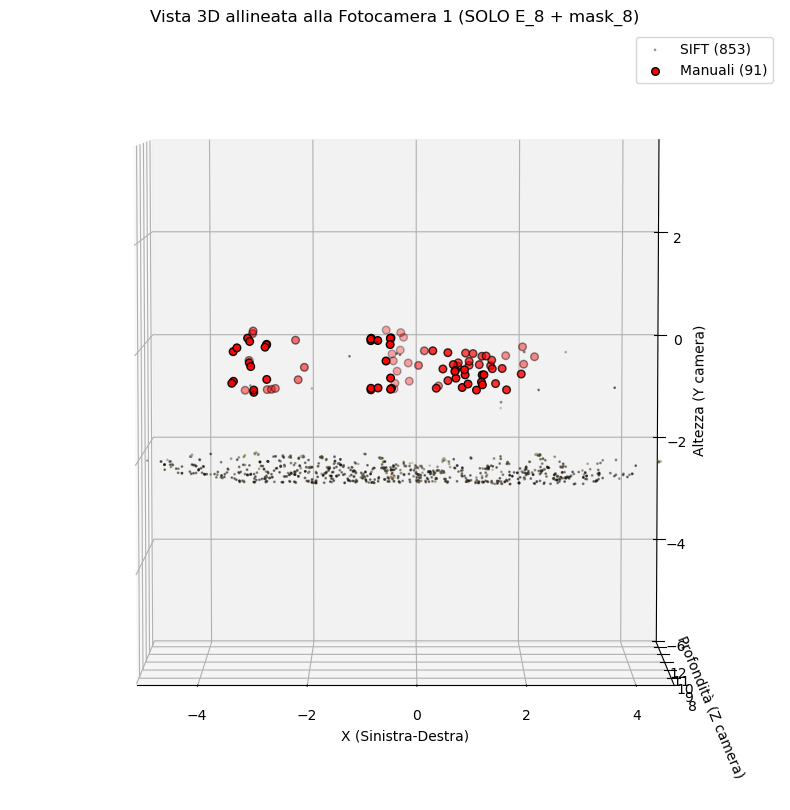

In [26]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG1_PATH = "object/img1.JPG"
CALIB_PATH = "camera_calib.npz"
E_RES_PATH = "outputs/E_results.npz"

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

img1 = cv2.imread(IMG1_PATH)
assert img1 is not None, "Errore caricamento img1."
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

cal = np.load(CALIB_PATH)
K = cal["K"].astype(np.float64)
dist = cal["dist"].astype(np.float64)

res = np.load(E_RES_PATH, allow_pickle=True)

# ============================================================
# MODIFICA 1: USA SOLO LA TUA SOLUZIONE (E_8 + mask_8)
# ============================================================
if "E_8" not in res:
    raise RuntimeError("E_8 non presente in E_results.npz: rigenera lo step2 salvando E_8.")

E = res["E_8"].astype(np.float64)

if "mask_8" not in res:
    raise RuntimeError(
        "mask_8 non presente in E_results.npz: non posso usare SOLO la tua E_8 in modo coerente.\n"
        "Rigenera E_results.npz con lo step2 che salva mask_8 (o modifica step2 per salvarla)."
    )

mask_in = res["mask_8"].astype(bool)
print("✅ Uso SOLO E_8 + mask_8 (nessun fallback su OpenCV)")

# ------------------------------------------------------------
# Caricamento punti
# ------------------------------------------------------------
if "pts1_px" not in res or "pts1_norm" not in res or "pts2_norm" not in res:
    raise RuntimeError(
        "Nel file E_results.npz mancano pts1_px / pts1_norm / pts2_norm.\n"
        "Assicurati che step2 salvi questi array."
    )

pts1_px = res["pts1_px"].astype(np.float64)
pts1_norm = res["pts1_norm"].astype(np.float64)
pts2_norm = res["pts2_norm"].astype(np.float64)

# opzionale: per distinguere punti manuali nel plot
src_is_manual = res["src_is_manual"].astype(bool) if "src_is_manual" in res else np.zeros(len(pts1_px), dtype=bool)

# Applica solo la tua mask_8
pts1_n = pts1_norm[mask_in].reshape(-1, 1, 2)
pts2_n = pts2_norm[mask_in].reshape(-1, 1, 2)
pts1_p = pts1_px[mask_in]
is_manual = src_is_manual[mask_in]

# ------------------------------------------------------------
# recoverPose con la tua E_8 (cameraMatrix = I perché punti norm)
# ------------------------------------------------------------
retval, R, t, mask_pose = cv2.recoverPose(E, pts1_n, pts2_n, np.eye(3))
mask_pose = mask_pose.ravel().astype(bool)

pts1_final_n = pts1_n[mask_pose].reshape(-1, 2)
pts2_final_n = pts2_n[mask_pose].reshape(-1, 2)
pts1_final_px = pts1_p[mask_pose].astype(np.int32)
is_manual_final = is_manual[mask_pose]

# ------------------------------------------------------------
# Triangolazione (coordinate normalizzate)
# ------------------------------------------------------------
P1 = np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = np.hstack([R, t])

X_h = cv2.triangulatePoints(P1, P2, pts1_final_n.T, pts2_final_n.T)
X = (X_h[:3, :] / (X_h[3, :] + 1e-12)).T

# Colori (nota: se pts1_px sono undistorti e img1 è distorta, i colori possono essere leggermente “shiftati”)
colors_bgr = np.array([img1_rgb[
    np.clip(pt[1], 0, img1_rgb.shape[0] - 1),
    np.clip(pt[0], 0, img1_rgb.shape[1] - 1)
] / 255.0 for pt in pts1_final_px])

# ------------------ FILTRI ------------------
X2 = (R @ X.T + t).T
mask_cheir = (X[:, 2] > 0) & (X2[:, 2] > 0)

dists_all = np.linalg.norm(X, axis=1)
th = np.quantile(dists_all[mask_cheir], 0.9) if np.sum(mask_cheir) > 0 else np.inf
mask_dist = dists_all < th

mask_keep = mask_cheir & mask_dist
X = X[mask_keep]
colors_bgr = colors_bgr[mask_keep]
is_manual_final = is_manual_final[mask_keep]

n_sift = int(np.sum(~is_manual_final))
n_manual = int(np.sum(is_manual_final))
print(f"Punti ricostruiti: {len(X)} (SIFT={n_sift}, MANUAL={n_manual})")

# ------------------ PLOT 3D ------------------
def transform_to_plot(pts):
    x_p = pts[:, 0]
    y_p = pts[:, 2]
    z_p = -pts[:, 1]
    return x_p, y_p, z_p

sift_mask = ~is_manual_final
manual_mask = is_manual_final

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

if np.sum(sift_mask) > 0:
    xs, ys, zs = transform_to_plot(X[sift_mask])
    ax.scatter(xs, ys, zs, c=colors_bgr[sift_mask], s=1, alpha=0.5, label=f"SIFT ({n_sift})")

if np.sum(manual_mask) > 0:
    xm, ym, zm = transform_to_plot(X[manual_mask])
    ax.scatter(xm, ym, zm, c="red", s=30, edgecolors="black", label=f"Manuali ({n_manual})")

ax.view_init(elev=5, azim=-90)
ax.set_xlabel("X (Sinistra-Destra)")
ax.set_ylabel("Profondità (Z camera)")
ax.set_zlabel("Altezza (Y camera)")

def safe_ptp(a, eps=1e-9):
    r = float(np.ptp(a))
    return r if r > eps else 1.0

x_all, y_all, z_all = transform_to_plot(X)
rx = safe_ptp(x_all)
ry = safe_ptp(y_all)

xmid = 0.5 * (x_all.min() + x_all.max())
ymid = 0.5 * (y_all.min() + y_all.max())
zmid = 0.5 * (z_all.min() + z_all.max())

ax.set_box_aspect([rx, ry, rx])
ax.set_xlim(xmid - rx / 2, xmid + rx / 2)
ax.set_ylim(ymid - ry / 2, ymid + ry / 2)
ax.set_zlim(zmid - rx / 2, zmid + rx / 2)

plt.title("Vista 3D allineata alla Fotocamera 1 (SOLO E_8 + mask_8)")
plt.legend()
plt.show()